In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_ab_test = pd.read_csv("ab_test_click_data.csv")

print(df_ab_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    20000 non-null  int64 
 1   click      20000 non-null  int64 
 2   group      20000 non-null  object
 3   timestamp  10000 non-null  object
dtypes: int64(2), object(2)
memory usage: 625.1+ KB
None


In [4]:
print(df_ab_test.describe())

            user_id         click
count  20000.000000  20000.000000
mean   10000.500000      0.405250
std     5773.647028      0.490953
min        1.000000      0.000000
25%     5000.750000      0.000000
50%    10000.500000      0.000000
75%    15000.250000      1.000000
max    20000.000000      1.000000


In [5]:
print(df_ab_test.groupby("group").sum("click"))

         user_id  click
group                  
con    150005000   1989
exp     50005000   6116


<Axes: xlabel='group', ylabel='count'>

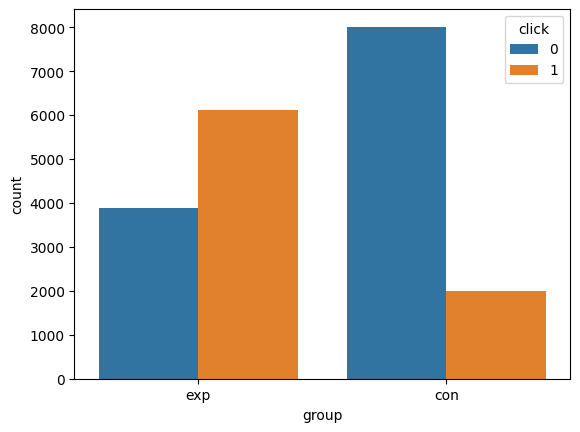

In [6]:
sns.countplot(x='group', hue='click', data=df_ab_test, )

In [7]:
alpha = 0.05
delta = 0.1

In [8]:
N_con = df_ab_test[df_ab_test["group"]=="con"]['click'].count()
N_exp = df_ab_test[df_ab_test["group"]=="exp"]['click'].count()

X_con = df_ab_test.groupby('group')['click'].sum().loc['con']
X_exp = df_ab_test.groupby('group')['click'].sum().loc['exp']



print(f"Total no. of clicks in Control : {X_con}")
print(f"Total no. of users in Control : {N_con}")
print(f"Total no. of clicks in Experimental : {X_exp}")
print(f"Total no. of users in Control : {N_exp}")

Total no. of clicks in Control : 1989
Total no. of users in Control : 10000
Total no. of clicks in Experimental : 6116
Total no. of users in Control : 10000


In [9]:
p_con_hat = X_con/N_con
p_exp_hat = X_exp/N_exp

print(f"Probability in Control Group : {p_con_hat}")
print(f"Probability in Exp Group : {p_exp_hat}")

p_pooled_hat = (X_con+X_exp)/(N_con+N_exp)
print(f"Pooled Probability : {p_pooled_hat}")

Probability in Control Group : 0.1989
Probability in Exp Group : 0.6116
Pooled Probability : 0.40525


In [10]:
pooled_variance = p_pooled_hat*(1-p_pooled_hat)*(1/N_con + 1/N_exp)
print(f"Pooled Variance : {pooled_variance}")

Pooled Variance : 4.82044875e-05


In [11]:
SE = np.sqrt(pooled_variance)
print(f"Standard Error  : {SE}")

Test_stat = (p_con_hat - p_exp_hat )/SE
print(f"Test Statistic (Z-test): {Test_stat}")

Z_crit = norm.ppf(1-alpha/2)
print(f"Critical Z-value : {Z_crit}")

Standard Error  : 0.006942945160376826
Test Statistic (Z-test): -59.44163326469381
Critical Z-value : 1.959963984540054


In [12]:
p_value = 2*norm.sf(abs(Test_stat))

def is_statistical_significance(p_val, alp):
    print(f"Given p-value is {p_val}")
    print(f"Alpha is {alp}")

    if p_val<alp:
        print("There is statistical significance since P-value < Alpha, i.e there is low chance that difference between groups is due to random chance")
    else:
        print("There is no statistical significance, high chance that differences between groups happened by chance")

is_statistical_significance(p_value, alpha)

Given p-value is 0.0
Alpha is 0.05
There is statistical significance since P-value < Alpha, i.e there is low chance that difference between groups is due to random chance


In [13]:
CI = [
    round((p_exp_hat - p_con_hat) - SE*Z_crit, 3),
    round((p_exp_hat - p_con_hat) + SE*Z_crit, 3),
]

print(f"Confidence Interval : {(CI)}")

Confidence Interval : [np.float64(0.399), np.float64(0.426)]


In [14]:
def is_practically_significant(delta, CI):
    lower_bound_CI = CI[0]

    if lower_bound_CI >= delta:
        print(f"Practical Significance with MDE {delta}. The difference between groups is practically significant.")
        return True
    else:
        print(f"No Practical Significance, difference btween the groups is not practically significant.")
        return False
    
significance = is_practically_significant(delta, CI)

Practical Significance with MDE 0.1. The difference between groups is practically significant.
